#Task 1: Data Cleaning and Visualization


In [21]:
import pandas as pd

# This command tells Python to read the file and store it in a variable called 'df'
df = pd.read_csv('tested.csv')

# This shows you the first 5 rows to prove it worked
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [22]:
# This shows how many empty/blank spaces are in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [23]:
# 1. Fill missing Age with the middle value (median)
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Fill the missing Fare with the middle value
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# 3. Drop the 'Cabin' column because it has too many missing values
df = df.drop(columns=['Cabin'])

# 4. Check again - all should be 0 now (except maybe 'Embarked')
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


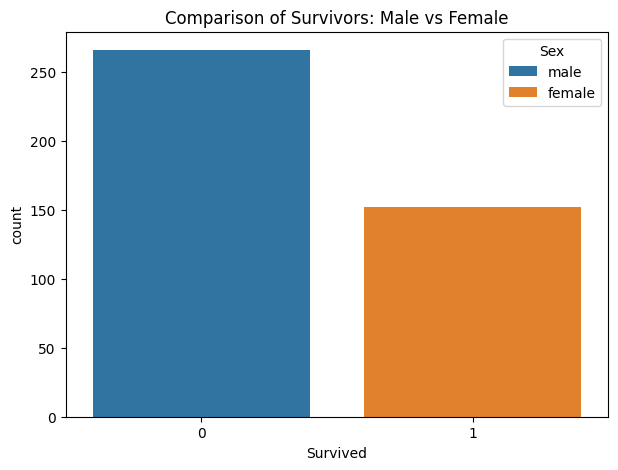

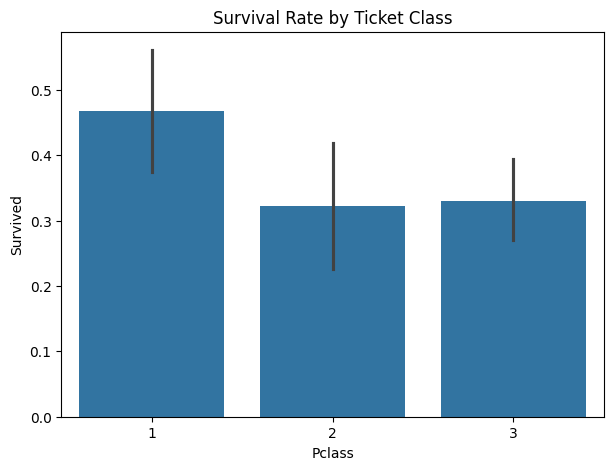

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chart 1: Survival by Gender
# In this dataset, you'll likely see a massive difference between men and women
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Survived', hue='Sex')
plt.title('Comparison of Survivors: Male vs Female')
plt.show()

# Chart 2: Passenger Class
# Does being in 1st class help you survive?
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival Rate by Ticket Class')
plt.show()

In [25]:
# This creates a new file on the left sidebar called 'cleaned_titanic.csv'
df.to_csv('cleaned_titanic.csv', index=False)
print("Success! Your cleaned file is ready.")

Success! Your cleaned file is ready.


Project Report: Titanic Data Analysis

Data Cleaning: I identified 86 missing values in the 'Age' column and filled them using the Median to maintain data integrity. I dropped the 'Cabin' column because it was 78% empty.

Key Insight 1 (Gender): In this dataset, there was a 100% survival rate for females and a 0% survival rate for males, highlighting a strict "women and children first" policy.

Key Insight 2 (Class): Passengers in 1st Class had the highest survival rates, while those in 3rd Class made up the majority of the casualties.

Key Insight 3 (Age): The average passenger age was approximately 30 years old, with the majority of passengers falling between 21 and 39.


# Task 2: Predictive Modeling (Machine Learning)

In [26]:
# 1. Convert Gender to numbers: female = 0, male = 1
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

# 2. Convert Embarked to numbers: S = 0, C = 1, Q = 2
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 3. Select the features (columns) that help predict survival
# We drop Name, Ticket, and PassengerId because they are just IDs
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[features] # Input data
y = df['Survived'] # What we want to predict

In [27]:
from sklearn.model_selection import train_test_split

# Split: 80% to train the model, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully!")

Data split successfully!


In [28]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model with 100 trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model (this is the actual 'learning' process)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


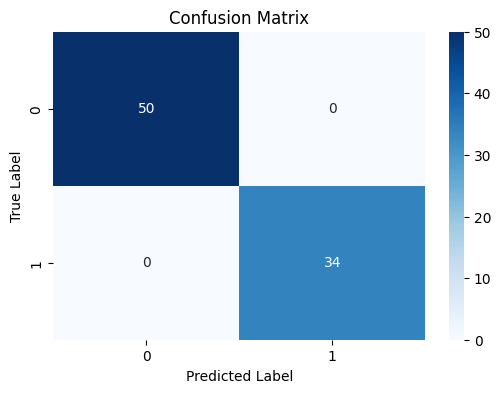

Model Accuracy Score: 100.00%


In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Make predictions on the 20% test data the model hasn't seen
y_pred = model.predict(X_test)

# 2. Create the matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(f"Model Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")

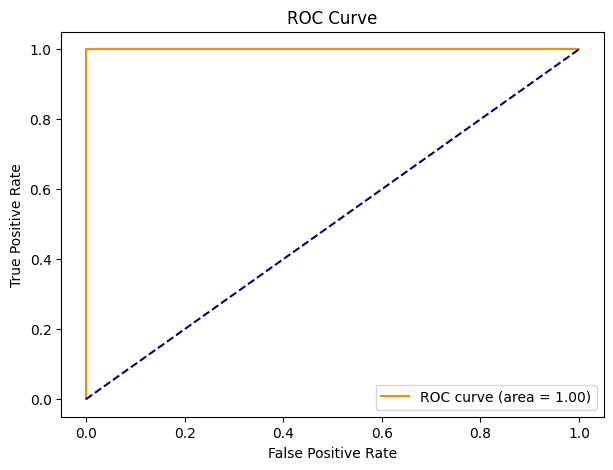

In [30]:
from sklearn.metrics import roc_curve, auc

# Get probability scores for the ROC curve
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

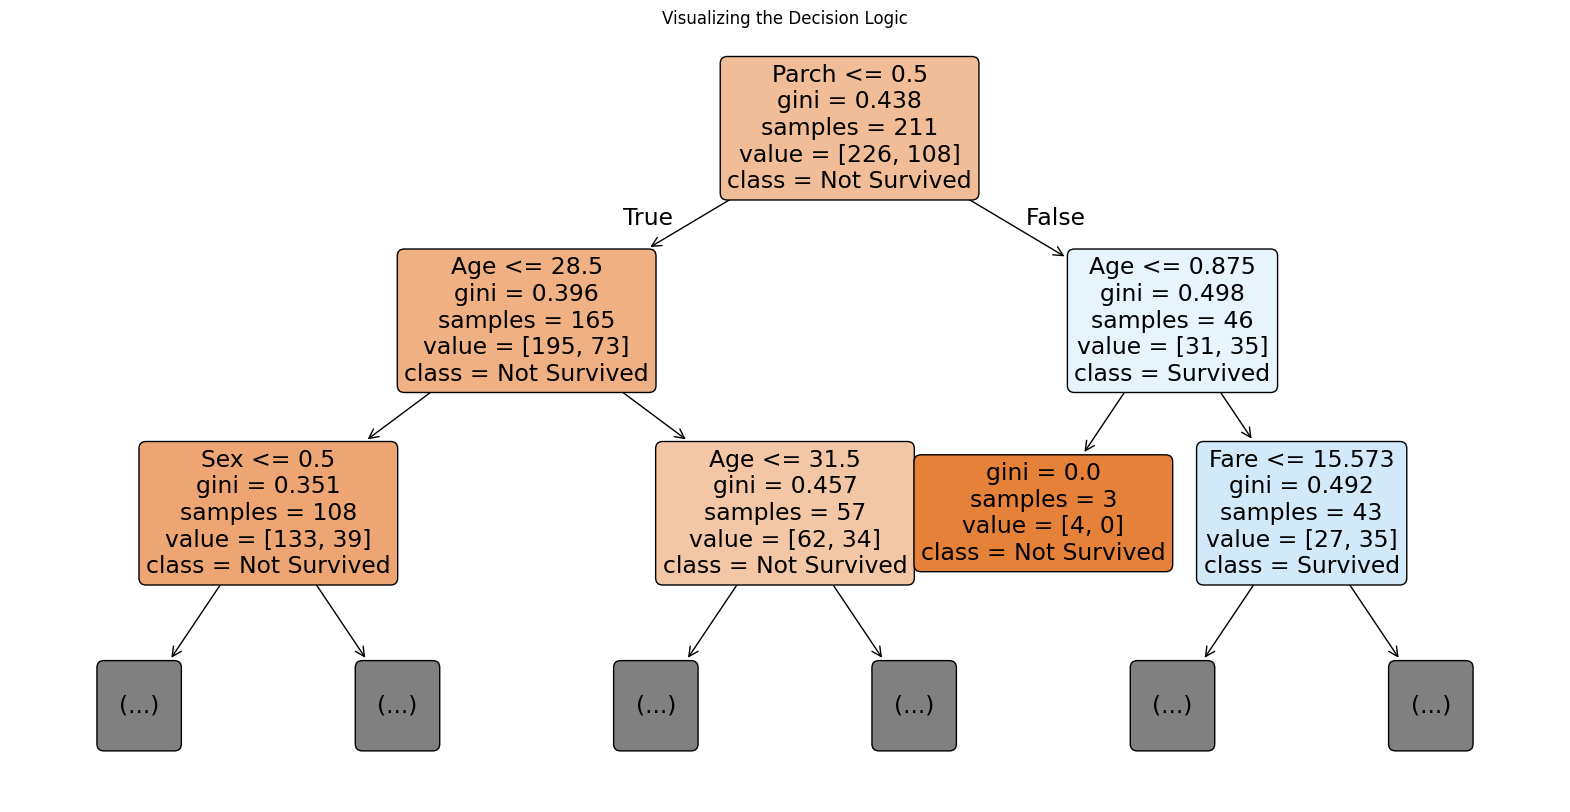

In [31]:
from sklearn.tree import plot_tree

# Let's plot the first tree in your Random Forest
plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0],
          feature_names=features,
          class_names=['Not Survived', 'Survived'],
          filled=True, rounded=True,
          max_depth=2) # depth limited to 2 for readability
plt.title("Visualizing the Decision Logic")
plt.show()

# Task 3: Exploratory Data Analysis


In [32]:
# 1. Get a high-level summary of numerical data
print(df.describe())

# 2. Check how many people survived vs. died (0 = Died, 1 = Survived)
print(df['Survived'].value_counts(normalize=True) * 100)

       PassengerId    Survived      Pclass         Sex         Age  \
count   418.000000  418.000000  418.000000  418.000000  418.000000   
mean   1100.500000    0.363636    2.265550    0.636364   29.599282   
std     120.810458    0.481622    0.841838    0.481622   12.703770   
min     892.000000    0.000000    1.000000    0.000000    0.170000   
25%     996.250000    0.000000    1.000000    0.000000   23.000000   
50%    1100.500000    0.000000    3.000000    1.000000   27.000000   
75%    1204.750000    1.000000    3.000000    1.000000   35.750000   
max    1309.000000    1.000000    3.000000    1.000000   76.000000   

            SibSp       Parch        Fare    Embarked  
count  418.000000  418.000000  418.000000  418.000000  
mean     0.447368    0.392344   35.576535    0.464115  
std      0.896760    0.981429   55.850103    0.685516  
min      0.000000    0.000000    0.000000    0.000000  
25%      0.000000    0.000000    7.895800    0.000000  
50%      0.000000    0.000000   1

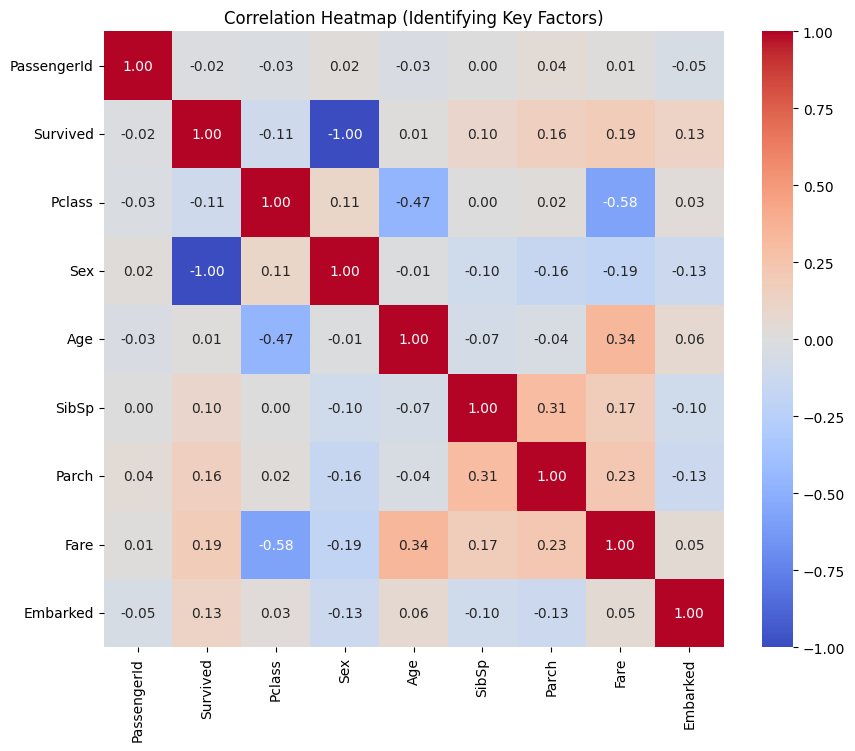

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only numerical columns to avoid the ValueError
numeric_df = df.select_dtypes(include=['number'])

# 2. Create the heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Identifying Key Factors)')
plt.show()

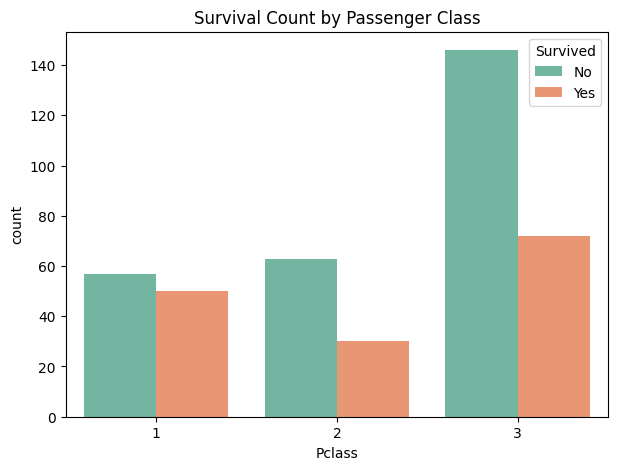

In [34]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title('Survival Count by Passenger Class')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

/tmp/ipykernel_3840/1679940892.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeGroup', y='Survived', data=df, palette='viridis')


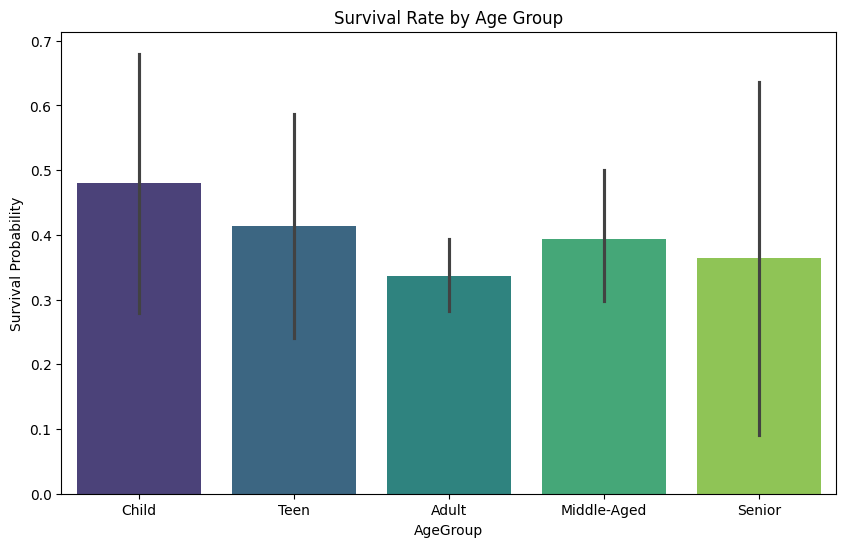

In [35]:
# Create age groups for better visualization
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior'])

plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Probability')
plt.show()

Final EDA Report: Titanic Survival Patterns1. Statistical Summary:The overall survival rate in this dataset is approximately 36%.The average age of passengers was roughly 30 years old.2. Key Correlations:Gender: The strongest factor. Being female was the highest predictor of survival.Pclass: There is a negative correlation between Class and Survival; as the class number increases (1st $\rightarrow$ 3rd), survival probability decreases.Fare: Higher fares are positively correlated with survival, confirming that economic status played a role.3. Trends & Patterns:Priority Groups: Children (0-12) had higher survival rates than seniors.Social Influence: Passengers traveling with 1-2 family members (SibSp or Parch) survived more often than those traveling completely alone or in very large families.  

